# Connecting Budget Bill to Fiscal Data
The codes contained in this file aim to integrate the budget bills for the 2023 fiscal year (FY) with fiscal data (covering the 30-month period through December 2025). Additionally, this file performs data visualization and analyses focused on specific items.

#### Prepare necessary packages

In [41]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

## 1. Create a prototype
We are using only the expenditure data from the 11th fiscal period of FY2023 (May 2024)

#### A. Define the function

In [42]:
def pad_code(val, length):
    if pd.isna(val) or val == '' or str(val).lower() == 'nan':
        return '0'.zfill(length)
    try:
        clean_val = str(int(float(val)))
        return clean_val.zfill(length)
    except:
        return str(val).zfill(length)

def get_final_bill_code(row):
    obj = str(row.get('object_code', '')).replace('.0', '').strip()
    proj = str(row.get('program_code', '')).replace('.0', '').strip()
    target = obj if (obj and obj not in ['0', 'nan', 'EMPTY']) else proj
    
    if not target or target == '0':
        return '0000'

    try:
        return str(int(float(target))).zfill(4)
    except:
        return target.zfill(4)


#### B. Prepare the Budget bill

In [43]:
Bill = "2023_Budget_Final_Amounts.csv"
bill_df = pd.read_csv(Bill)

print("The first few rows of the bill dataframe are:")
print(bill_df.head())

# Extract relevant columns and create new DataFrame for processing
bill_df_new = bill_df[["item_number", "program_code", "object_code", "revised_amount"]].copy()

# Extract business_unit, budget_reference, fund_code from item_number
bill_df_new[["business_unit", "budget_reference", "fund_code"]] = bill_df_new["item_number"].str.split("-", expand=True)

# Padding for business_unit, budget_reference, fund_code
bill_df_new['clean_bu'] = bill_df_new['business_unit'].apply(lambda x: pad_code(x, 4))
bill_df_new['clean_ref'] = bill_df_new['budget_reference'].apply(lambda x: pad_code(x, 3))
bill_df_new['clean_fund'] = bill_df_new['fund_code'].apply(lambda x: pad_code(x, 4))

# Create Budget_ID using the cleaned components and the final bill code logic
bill_df_new['Budget_ID'] = (
    "2023-" + 
    bill_df_new['clean_bu'] + "-" + 
    bill_df_new['clean_ref'] + "-" + 
    bill_df_new['clean_fund'] + "-" + 
    bill_df_new.apply(get_final_bill_code, axis=1).apply(lambda x: str(x).zfill(7) if len(str(x)) >= 5 else str(x).zfill(4))
)

# Again, show the first few rows to verify the new Budget_ID column
print("\nThe first few rows of the processed bill dataframe with Budget_ID are:")
print(bill_df_new.head())

The first few rows of the bill dataframe are:
     item_number program_code object_code  fund_code  revised_amount
0  0110-001-0001        EMPTY    101001.0          1         6751000
1  0110-001-0001        EMPTY    317292.0          1         1712000
2  0110-001-0001        EMPTY    317295.0          1           11000
3  0110-001-0001        EMPTY    500004.0          1       168851000
4  0120-011-0001        EMPTY    101001.0          1        14600000

The first few rows of the processed bill dataframe with Budget_ID are:
     item_number program_code object_code  revised_amount business_unit  \
0  0110-001-0001        EMPTY    101001.0         6751000          0110   
1  0110-001-0001        EMPTY    317292.0         1712000          0110   
2  0110-001-0001        EMPTY    317295.0           11000          0110   
3  0110-001-0001        EMPTY    500004.0       168851000          0110   
4  0120-011-0001        EMPTY    101001.0        14600000          0120   

  budget_referenc

#### C. Process fiscal data and merge with bill data

In [44]:
Fiscal = "Vendor_FY23P11.csv"
temp_fiscal = pd.read_csv(Fiscal, low_memory=False)

# Limit to fiscal year 2023
temp_fiscal = temp_fiscal[temp_fiscal['year_of_enactment'] == 2023].copy()

# Padding for business_unit, budget_reference, fund_code in fiscal data
temp_fiscal['clean_bu'] = temp_fiscal['business_unit'].apply(lambda x: pad_code(x, 4))
temp_fiscal['clean_ref'] = temp_fiscal['budget_reference'].apply(lambda x: pad_code(x, 3))
temp_fiscal['clean_fund'] = temp_fiscal['fund_code'].apply(lambda x: pad_code(x, 4))

# Create a raw program code column that is numeric and zero-padded to 10 digits
temp_fiscal['prog_raw'] = (
    pd.to_numeric(temp_fiscal['program_code'], errors='coerce')
    .fillna(0)
    .astype(int)
    .astype(str)
)

# Create two versions of Budget_ID for matching: one with 7 digits and one with 4 digits
temp_fiscal['Budget_ID_7'] = "2023-" + temp_fiscal['clean_bu'] + "-" + temp_fiscal['clean_ref'] + "-" + temp_fiscal['clean_fund'] + "-" + temp_fiscal['prog_raw'].str.zfill(10).str[:7]
temp_fiscal['Budget_ID_4'] = "2023-" + temp_fiscal['clean_bu'] + "-" + temp_fiscal['clean_ref'] + "-" + temp_fiscal['clean_fund'] + "-" + temp_fiscal['prog_raw'].str.zfill(10).str[:4]

# Excecute the matching in two steps
m1 = pd.merge(bill_df_new, temp_fiscal, left_on='Budget_ID', right_on='Budget_ID_7', how='inner', suffixes=('', '_f'))
matched_ids = m1['Budget_ID'].unique()
unmatched_bill = bill_df_new[~bill_df_new['Budget_ID'].isin(matched_ids)]
m2 = pd.merge(unmatched_bill, temp_fiscal, left_on='Budget_ID', right_on='Budget_ID_4', how='inner', suffixes=('', '_f'))

# Merge and create the final report
p01_merged = pd.concat([m1, m2], ignore_index=True)

final_report_p01 = pd.merge(bill_df_new, p01_merged, on='Budget_ID', how='left', suffixes=('', '_final'))

#### D. Calculate the ratio of matching status

In [45]:
print(f"Total rows in CSV: {len(temp_fiscal):,}")

print("\n--- Year of Enactment Status ---")
print(f"Data Type: {temp_fiscal['year_of_enactment'].dtype}")
print(temp_fiscal['year_of_enactment'].value_counts().head(10))

count_int = len(temp_fiscal[temp_fiscal['year_of_enactment'] == 2023])
count_str = len(temp_fiscal[temp_fiscal['year_of_enactment'].astype(str).str.contains('2023', na=False)])
print(f"\nCount as Int: {count_int}")
print(f"Count as Str: {count_str}")

Total rows in CSV: 266,283

--- Year of Enactment Status ---
Data Type: int64
year_of_enactment
2023    266283
Name: count, dtype: int64

Count as Int: 266283
Count as Str: 266283


#### E. Look for "9999"

In [46]:
clearing_spending = temp_fiscal[
    (temp_fiscal['year_of_enactment'] == 2023) & 
    (temp_fiscal['prog_raw'].str.startswith('9999')) 
]

total_count = len(clearing_spending)
total_amount = clearing_spending['monetary_amount'].sum()

print(f"--- 9999 (Clearing Account) Analysis ---")
print(f"total count: {total_count:,} ")
print(f"total amount: ${total_amount:,.2f}")

# View top 5 departments using 9999
print("\n--- Top 5 Departments using 9999 ---")
print(clearing_spending.groupby('business_unit').size().sort_values(ascending=False).head(5))

--- 9999 (Clearing Account) Analysis ---
total count: 135,539 
total amount: $252,786,230.65

--- Top 5 Departments using 9999 ---
business_unit
8955    16234
2720    12155
3790    11360
7100    11039
3600    10580
dtype: int64


#### F. Extract "Non-Budget Act" items

In [47]:
non_budget_2023 = temp_fiscal[
    (temp_fiscal['year_of_enactment'] == 2023) & 
    (temp_fiscal['budget_reference_sub_category'] == 'Non-Budget Act')
]

print(f"--- Non-Budget Act Analysis (FY2023) ---")
print(f"total count: {len(non_budget_2023):,} ")
print(f"total amount: ${non_budget_2023['monetary_amount'].sum():,.2f}")

--- Non-Budget Act Analysis (FY2023) ---
total count: 399 
total amount: $109,977,015.52


#### G. Specify "Unmatched" or "Error" items

In [48]:
true_lost_2023 = temp_fiscal[
    (temp_fiscal['year_of_enactment'] == 2023) & 
    (temp_fiscal['budget_reference_sub_category'] == 'Budget Act') & 
    (~temp_fiscal['prog_raw'].str.startswith('9999')) & 
    (~temp_fiscal['Budget_ID_7'].isin(bill_df_new['Budget_ID'])) & # 7桁でチェック
    (~temp_fiscal['Budget_ID_4'].isin(bill_df_new['Budget_ID']))   # 4桁でチェック
]

# Show a sample of the true lost cases
if not true_lost_2023.empty:
    sample = true_lost_2023.iloc[0] 
    
    print(f"total count of true lost cases: {len(true_lost_2023):,} ")
    print("\n--- Sample of True Lost Cases ---")
    print(f"Agency Name:        {sample.get('agency_name', 'N/A')}")
    print(f"Business Unit (BU): {sample['business_unit']}")
    print(f"Budget Reference:   {sample['budget_reference']}")
    print(f"Fund Code:          {sample['fund_code']}")
    print(f"Program Code:       {sample['program_code']}")
    print(f"Actual Spending ($): {sample['monetary_amount']:,.2f}")
    print("-" * 30)
    # Show the generated Budget_IDs for debugging
    print(f"Generated ID_7:     {sample['Budget_ID_7']}")
    print(f"Generated ID_4:     {sample['Budget_ID_4']}")
    print(f"Vendor Name:        {sample.get('VENDOR_NAME', 'N/A')}")
else:
    print("No true lost cases found for FY2023 with the given criteria.")

total count of true lost cases: 3,309 

--- Sample of True Lost Cases ---
Agency Name:        Labor & Workforce Development
Business Unit (BU): 7100
Budget Reference:   101
Fund Code:          869
Program Code:       5940064000
Actual Spending ($): 4,327,715.42
------------------------------
Generated ID_7:     2023-7100-101-0869-5940064
Generated ID_4:     2023-7100-101-0869-5940
Vendor Name:        EMPLOYMENT DEVELOPMENT DEPT


#### H. Visualize this ratio using a pie chat

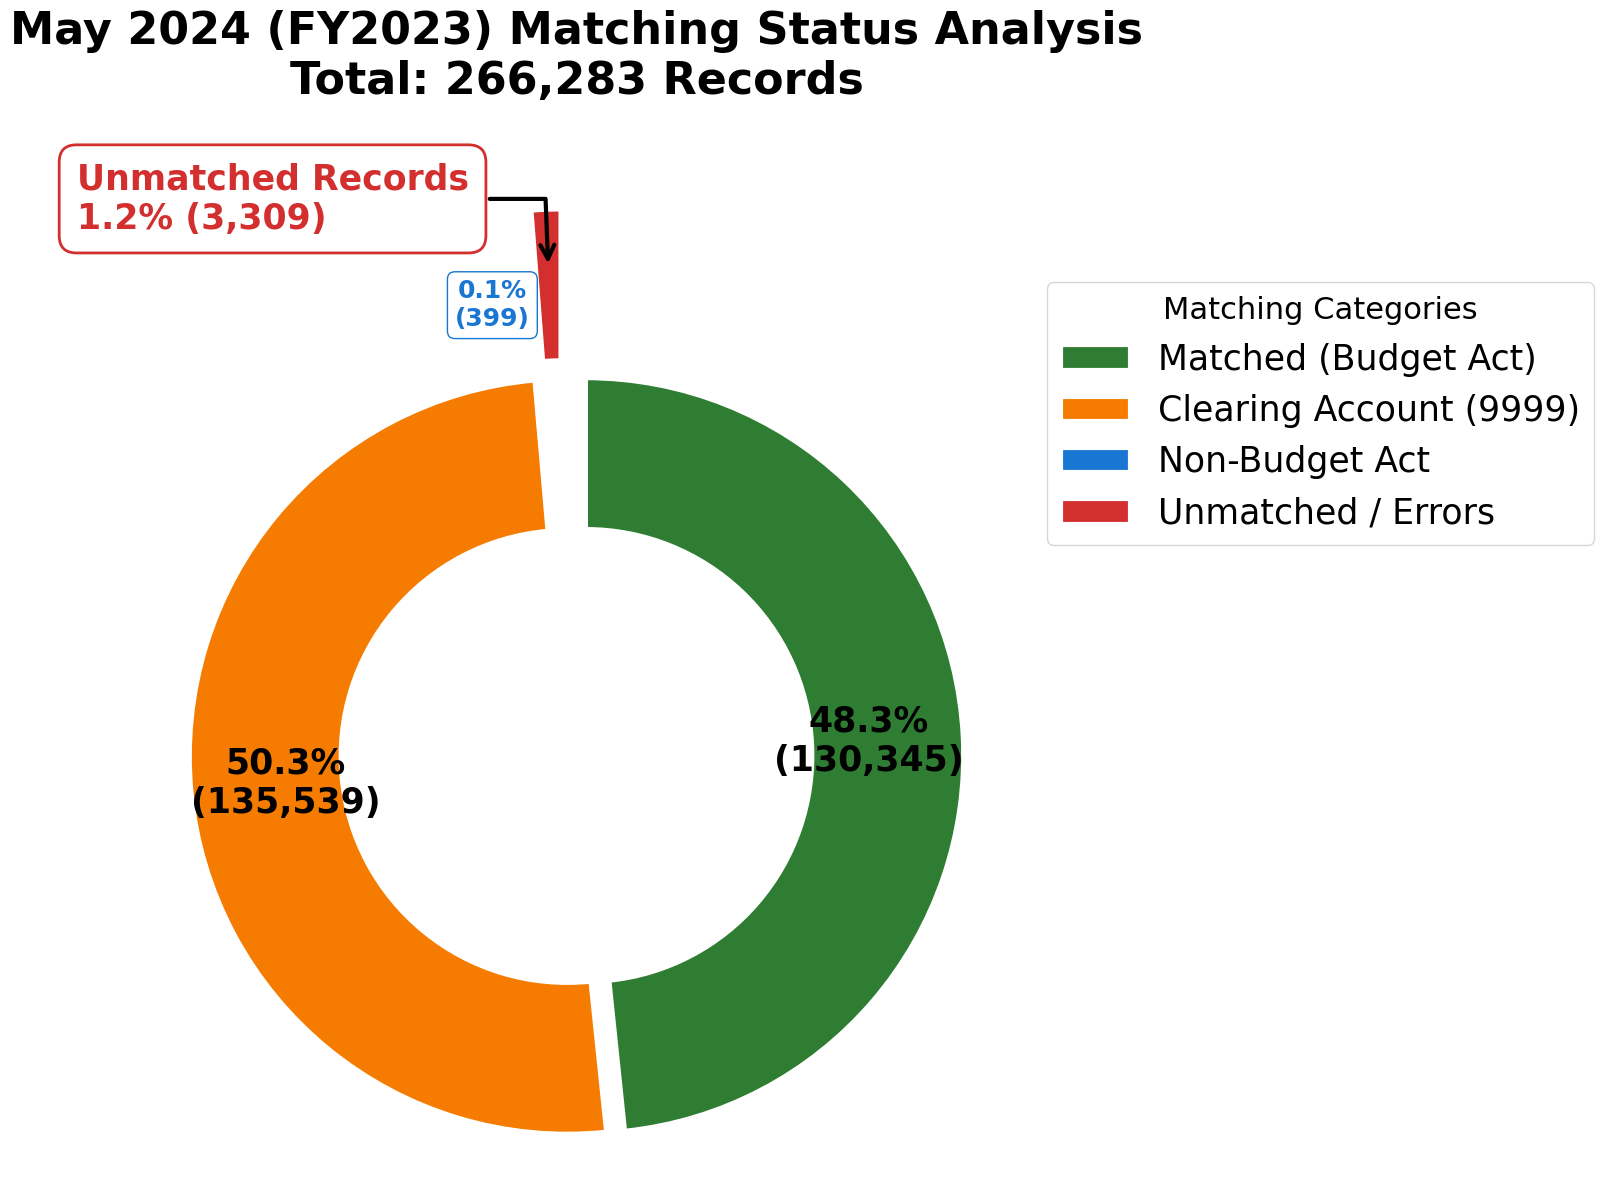

In [49]:
# Define the data for the pie chart
labels = ['Matched (Budget Act)', 'Clearing Account (9999)', 'Non-Budget Act', 'Unmatched / Errors']
sizes = [130345, 135539, 399, 3309]   # These numbers should be updated based on the actual counts from the previous analysis
colors = ['#2E7D32', '#F57C00', '#1976D2', '#D32F2F']
explode = (0.05, 0, 0.25, 0.45) 

total = sum(sizes)

plt.figure(figsize=(15, 12))

wedges, texts, autotexts = plt.pie(
    sizes, 
    explode=explode, 
    colors=colors,
    # Show percentage and count only for slices larger than 5% to avoid clutter
    autopct=lambda p: '{:.1f}%\n({:,.0f})'.format(p, p * total / 100) if p > 5 else '',
    shadow=False, 
    startangle=90, 
    counterclock=False, 
    pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 3},
    textprops={'fontsize': 25, 'fontweight': 'bold'} 
)

plt.setp(autotexts, size=25, weight="bold")

plt.legend(wedges, labels, 
           title="Matching Categories", 
           loc="upper left", 
           bbox_to_anchor=(1, 0.9), 
           fontsize=25, 
           title_fontsize=22,
           frameon=True)

# Emphasize the small slices with annotations
ang2 = (wedges[2].theta2 + wedges[2].theta1) / 2.
y2 = np.sin(np.deg2rad(ang2))
x2 = np.cos(np.deg2rad(ang2))
plt.text(x2*1.2 - 0.1 , y2*1.2, '0.1%\n(399)', 
         fontsize=18, fontweight='bold', color='#1976D2', 
         ha='center', va='center', 
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1976D2", lw=1))

ang3 = (wedges[3].theta2 + wedges[3].theta1) / 2.
y3 = np.sin(np.deg2rad(ang3))
x3 = np.cos(np.deg2rad(ang3))

plt.annotate(
    "Unmatched Records\n1.2% (3,309)", 
    xy=(x3*1.3, y3*1.3),
    xytext=(1.5*np.sign(x3) + 0.2 , 1.4*y3),
    arrowprops=dict(arrowstyle="->", color="black", lw=3, connectionstyle=f"angle,angleA=0,angleB={ang3}"),
    fontsize=25,
    color='#D32F2F',
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#D32F2F", lw=2)
)

plt.title('May 2024 (FY2023) Matching Status Analysis\nTotal: 266,283 Records', 
          fontsize=32, fontweight='bold', pad=50)

plt.axis('equal')
plt.tight_layout()

# Save as PNG
plt.savefig('matching_status_top_start.png', dpi=300, bbox_inches='tight')

#### I. Output as a CSV file

In [50]:
# 1. Detail Report
detail_cols = [
    'Budget_ID', 
    'year_of_enactment', 
    'business_unit', 
    'agency_name', 
    'department_name',  
    'revised_amount', 
    'monetary_amount', 
    'VENDOR_NAME', 
    'accounting_date'
]
final_report_clean = final_report_p01[[c for c in detail_cols if c in final_report_p01.columns]].copy()
final_report_clean.to_csv("Detail_FY23P01.csv", index=False, encoding='utf-8-sig')

# 2. Crosswalk Table
crosswalk_cols = [
    'Budget_ID', 
    'agency_name',      
    'department_name',  
    'program_description'
]
crosswalk_p01 = final_report_p01[final_report_p01['monetary_amount'].notna()][
    [c for c in crosswalk_cols if c in final_report_p01.columns]
].drop_duplicates()
crosswalk_p01.to_csv("Crosswalk_FY23P11.csv", index=False, encoding='utf-8-sig')

print(f"P01 Processing Complete.")
print(f"Matched rows: {final_report_p01['monetary_amount'].notna().sum()}")

P01 Processing Complete.
Matched rows: 126739


## 2. Expand all fiscal data

In [51]:
# Prepare an empty list to collect monthly merged dataframes
final_combined_list = []

# Designate the path to the folder containing the actual expenditure data files (Vendor_FY2*P*.csv)
file_pattern = "Vendor_FY2*P*.csv" 
files = glob.glob(file_pattern)
files.sort()

print(f"Total {len(files)} files to process...")

all_reports = [] 

for file in files:
    print(f"Processing: {file}")
    temp_fiscal = pd.read_csv(file, low_memory=False)

    temp_fiscal = temp_fiscal[temp_fiscal['year_of_enactment'] == 2023].copy()
    
    temp_fiscal['clean_bu'] = temp_fiscal['business_unit'].apply(lambda x: pad_code(x, 4))
    temp_fiscal['clean_ref'] = temp_fiscal['budget_reference'].apply(lambda x: pad_code(x, 3))
    temp_fiscal['clean_fund'] = temp_fiscal['fund_code'].apply(lambda x: pad_code(x, 4))
    
    temp_fiscal['prog_str'] = (
        pd.to_numeric(temp_fiscal['program_code'], errors='coerce')
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(10)
    )
    temp_fiscal['Budget_ID_7'] = "2023-" + temp_fiscal['clean_bu'] + "-" + temp_fiscal['clean_ref'] + "-" + temp_fiscal['clean_fund'] + "-" + temp_fiscal['prog_str'].str[:7]
    temp_fiscal['Budget_ID_4'] = "2023-" + temp_fiscal['clean_bu'] + "-" + temp_fiscal['clean_ref'] + "-" + temp_fiscal['clean_fund'] + "-" + temp_fiscal['prog_str'].str[:4]

    # First, try to match using the 7-digit ID, then for unmatched records, try the 4-digit ID
    m1 = pd.merge(bill_df_new, temp_fiscal, left_on='Budget_ID', right_on='Budget_ID_7', how='inner', suffixes=('', '_f'))
    matched_ids = m1['Budget_ID'].unique()
    unmatched_bill = bill_df_new[~bill_df_new['Budget_ID'].isin(matched_ids)]
    m2 = pd.merge(unmatched_bill, temp_fiscal, left_on='Budget_ID', right_on='Budget_ID_4', how='inner', suffixes=('', '_f'))

    monthly_matched = pd.concat([m1, m2], ignore_index=True).drop_duplicates()
    
    all_reports.append(monthly_matched)

full_year_df = pd.concat(all_reports, ignore_index=True)

final_report_clean = pd.merge(bill_df_new, full_year_df, on='Budget_ID', how='left', suffixes=('', '_final'))

Total 30 files to process...
Processing: Vendor_FY23P01.csv
Processing: Vendor_FY23P02.csv
Processing: Vendor_FY23P03.csv
Processing: Vendor_FY23P04.csv
Processing: Vendor_FY23P05.csv
Processing: Vendor_FY23P06.csv
Processing: Vendor_FY23P07.csv
Processing: Vendor_FY23P08.csv
Processing: Vendor_FY23P09.csv
Processing: Vendor_FY23P10.csv
Processing: Vendor_FY23P11.csv
Processing: Vendor_FY23P12.csv
Processing: Vendor_FY24P01.csv
Processing: Vendor_FY24P02.csv
Processing: Vendor_FY24P03.csv
Processing: Vendor_FY24P04.csv
Processing: Vendor_FY24P05.csv
Processing: Vendor_FY24P06.csv
Processing: Vendor_FY24P07.csv
Processing: Vendor_FY24P08.csv
Processing: Vendor_FY24P09.csv
Processing: Vendor_FY24P10.csv
Processing: Vendor_FY24P11.csv
Processing: Vendor_FY24P12.csv
Processing: Vendor_FY25P01.csv
Processing: Vendor_FY25P02.csv
Processing: Vendor_FY25P03.csv
Processing: Vendor_FY25P04.csv
Processing: Vendor_FY25P05.csv
Processing: Vendor_FY25P06.csv


In [52]:
# --- Step 1: Unique-ify the Master List first ---
# This ensures we have exactly one row per Budget_ID as the baseline.
master_unique = bill_df_new.groupby('Budget_ID').agg({
    'revised_amount': 'first'
}).reset_index()

# --- Step 2: Aggregate Expenditure Data ---
# Condense transactions into one row per Budget_ID.
expenditure_summary = final_report_clean.groupby('Budget_ID').agg({
    'monetary_amount': 'sum',
    'agency_name': 'first',
    'department_name': 'first'
}).reset_index()

# --- Step 3: Left Join (Unique Master + Aggregated Expenditure) ---
# This will result in exactly the same number of rows as your unique Master List.
summary_report = pd.merge(
    master_unique, 
    expenditure_summary, 
    on='Budget_ID', 
    how='left'
)

# --- Step 4: Final Cleanup and Calculation ---
summary_report['monetary_amount'] = summary_report['monetary_amount'].fillna(0)
summary_report['agency_name'] = summary_report['agency_name'].fillna("Inactive/No Spending")

summary_report['Spending_Rate'] = (summary_report['monetary_amount'] / summary_report['revised_amount']) * 100

# --- Step 5: Save ---
summary_report.to_csv("Budget_Spending_Summary_FY23-25.csv", index=False, encoding='utf-8-sig')

print(f"Success! Final count: {len(summary_report)} budget items.")

Success! Final count: 2590 budget items.


In [53]:
# Check the number of rows in final_report_clean and summary_report
print(f"Final Report Rows: {len(final_report_clean)}")
print(f"Summary Report Rows: {len(summary_report)}")

Final Report Rows: 1612105
Summary Report Rows: 2590


### Make a Crosswalk table 

In [54]:
crosswalk_df = final_report_clean[final_report_clean['monetary_amount'].notna()].copy()

crosswalk_cols = [
    'Budget_ID', 
    'agency_name',      
    'department_name',  
    'program_description'
]

crosswalk_table = crosswalk_df[[c for c in crosswalk_cols if c in crosswalk_df.columns]].drop_duplicates()

crosswalk_table.to_csv("Final_Crosswalk_Table_FY23-25.csv", index=False, encoding='utf-8-sig')

print(f"Complete! The crosswalk table (Final_Crosswalk_Table_FY23-25.csv) has been created.")
print(f"Valid pairs: {len(crosswalk_table)}")

Complete! The crosswalk table (Final_Crosswalk_Table_FY23-25.csv) has been created.
Valid pairs: 1315


## 3. For Visualization
### Create monthly summary

In [55]:
# Convert accounting_date to datetime
final_report_clean['accounting_date'] = pd.to_datetime(
    final_report_clean['accounting_date'], 
    format='mixed', 
    dayfirst=False
)

# Create YearMonth column for grouping
final_report_clean['YearMonth'] = final_report_clean['accounting_date'].dt.to_period('M')

# Group by Budget_ID and YearMonth to get monthly spending summary
monthly_summary = final_report_clean.groupby(['Budget_ID', 'YearMonth']).agg({
    'monetary_amount': 'sum',       # Spendings for that month
    'revised_amount': 'first',      # Budget amount (for comparison)
    'agency_name': 'first'          # Agency name (for reference)
}).reset_index()

# Convert YearMonth to string for CSV saving and Power BI compatibility
monthly_summary['YearMonth'] = monthly_summary['YearMonth'].astype(str)

# Save the monthly summary to a new CSV file
monthly_summary.to_csv("Monthly_Budget_Spending_FY23-25.csv", index=False, encoding='utf-8-sig')

print(f"Monthly summary creation completed: {len(monthly_summary)} rows")

Monthly summary creation completed: 14702 rows


#### Create a pie chart that shows whole progress rate.

In [56]:
# Create a pie chart that shows whole progress rate
# Utilize "summary_report"
# At first, we will calculate the overall spending rate across all budgets for FY23
overall_revised = summary_report['revised_amount'].sum()
overall_spent = summary_report['monetary_amount'].sum()
overall_spending_rate = (overall_spent / overall_revised) * 100 if overall_revised > 0 else 0
print(f"Overall Spending Rate for FY23: {overall_spending_rate:.2f}%")

Overall Spending Rate for FY23: 8.25%


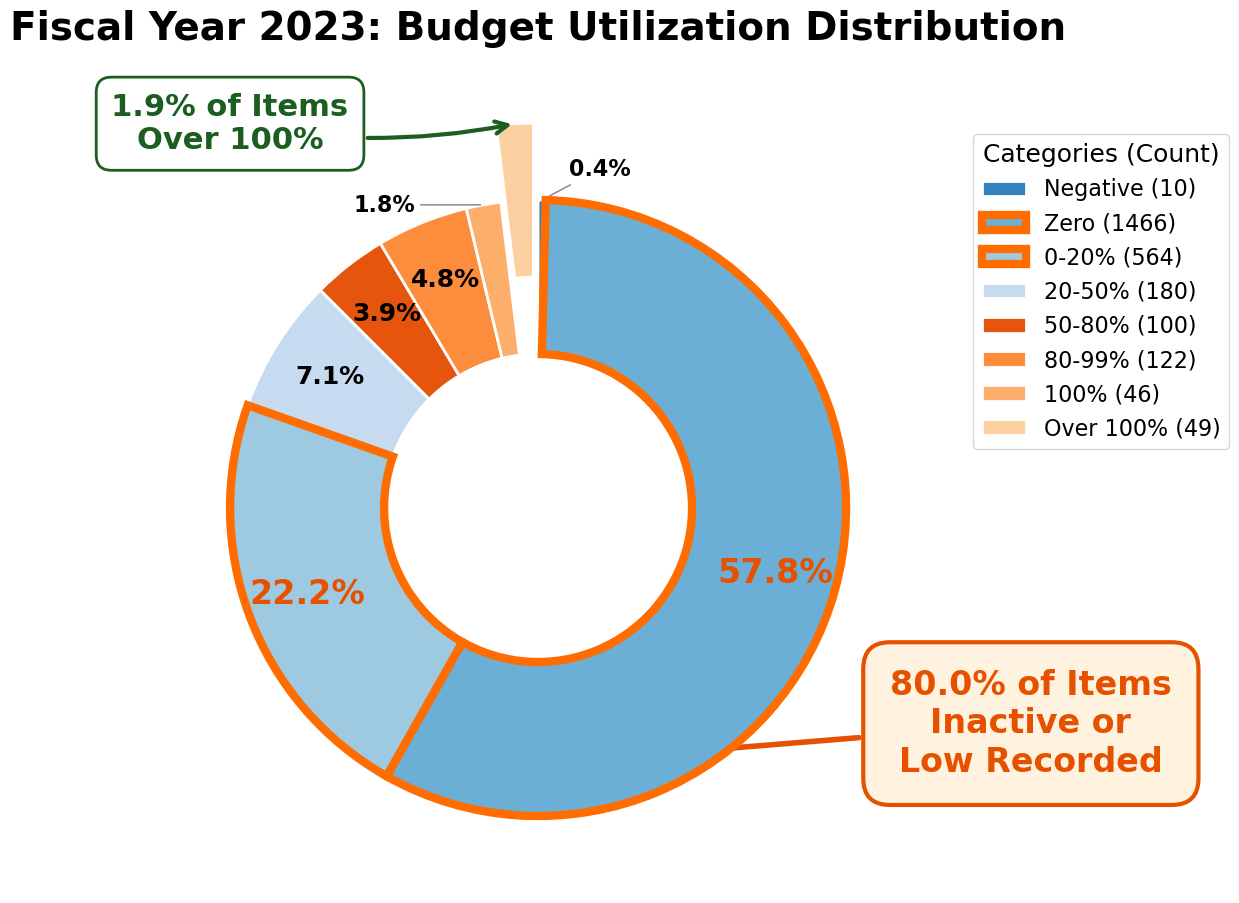

In [57]:
summary_report['Spending_Category'] = pd.cut(
    summary_report['Spending_Rate'],
    bins=[-np.inf, -0.000001, 0.000001, 20, 50, 80, 99.9999, 100, np.inf],
    labels=['Negative', 'Zero', '0-20%', '20-50%', '50-80%', '80-99%', '100%', 'Over 100%'],
    right=True 
)

category_counts = summary_report['Spending_Category'].value_counts().sort_index()
labels = category_counts.index.tolist()
explode = [0, 0, 0, 0, 0, 0, 0, 0.25] 

fig, ax = plt.subplots(figsize=(14, 10))

pie_elements = ax.pie(
    category_counts, explode=explode, labels=labels,
    startangle=90, counterclock=False, pctdistance=0.8,
    wedgeprops={'width': 0.5, 'edgecolor': 'w', 'linewidth': 2},
    colors=plt.cm.tab20c.colors, autopct='%1.1f%%'
)

wedges, texts, autotexts = pie_elements[0], pie_elements[1], pie_elements[2]
for t in texts: t.set_visible(False)

for i in [1, 2]:
    wedges[i].set_edgecolor('#FF6D00')
    wedges[i].set_linewidth(6)
    wedges[i].set_zorder(5)

for i, a in enumerate(autotexts):
    pct = category_counts.iloc[i] / category_counts.sum() * 100
    a.set_zorder(20) 
    if i in [1, 2]: 
        a.set_text(f"{pct:.1f}%")
        a.set_size(24); a.set_color('#E65100'); a.set_weight("bold")
    elif pct < 2.0: 
        a.set_text(""); a.set_visible(False)
    else:
        a.set_text(f"{pct:.1f}%"); a.set_size(18); a.set_weight("bold")

def add_simple_note(idx, text, color, offset_x=1.8, offset_y=1.2):
    ang = (wedges[idx].theta2 + wedges[idx].theta1) / 2.
    y, x = np.sin(np.deg2rad(ang)), np.cos(np.deg2rad(ang))
    ax.annotate(
        text, xy=(x, y), xytext=(offset_x * np.sign(x), offset_y * y),
        arrowprops=dict(arrowstyle="-", color="gray", lw=1), 
        fontsize=16, color="black", fontweight='bold',
        ha='center', va='center'
    )

def add_bold_callout(idx, text, color, offset_x=1.5, offset_y=1.2):
    ang = (wedges[idx].theta2 + wedges[idx].theta1) / 2.
    y, x = np.sin(np.deg2rad(ang)), np.cos(np.deg2rad(ang))
    if idx == 7: x, y = x*1.25, y*1.25 
    ax.annotate(
        text, xy=(x, y), xytext=(offset_x * np.sign(x), offset_y * y),
        arrowprops=dict(arrowstyle="->", color=color, lw=3, connectionstyle="arc3,rad=0.1"),
        fontsize=22, color=color, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec=color, lw=2),
        ha='center', va='center'
    )


add_simple_note(0, "0.4%", "#546E7A", offset_x=0.2, offset_y=1.1)
add_simple_note(6, "1.8%", "#0288D1", offset_x=0.5, offset_y=1.0)

add_bold_callout(7, f"1.9% of Items\nOver 100%", "#1B5E20", offset_x=1.0, offset_y=1.0)

ang_mid = (wedges[1].theta1 + wedges[2].theta2) / 2.
y_mid, x_mid = np.sin(np.deg2rad(ang_mid)), np.cos(np.deg2rad(ang_mid))

ax.annotate(
    "80.0% of Items\nInactive or\nLow Recorded",
    xy=(x_mid, y_mid),             
    xytext=(1.6, -0.7),            
    fontsize=24, 
    color='#E65100', 
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.8", fc="#FFF3E0", ec="#E65100", lw=3),
    arrowprops=dict(
        arrowstyle="->",            
        color="#E65100", 
        lw=4,                        
        connectionstyle="arc3,rad=0" 
    ),
    ha='center',
    va='center'
)

plt.title('Fiscal Year 2023: Budget Utilization Distribution', pad=60, fontsize=28, fontweight='bold')
ax.legend(
    wedges, 
    [f'{l} ({v})' for l, v in zip(category_counts.index, category_counts.values)],
    title="Categories (Count)",
    title_fontsize=18,
    loc="upper left",         
    bbox_to_anchor=(1.05, 1),  
    fontsize=16,
    frameon=True               
)

plt.savefig('budget_utilization_pie_chart.png', dpi=300, bbox_inches='tight')

plt.show()

## 4. Focusing on 6120 (California State Library)

#### Create the progress report for 6120

In [61]:
print("\n--- Calculating Progress Rate for Dept of Education (6120) ---")

master_6120 = bill_df_new[bill_df_new['Budget_ID'].str.startswith('2023-6120', na=False)].copy()

total_spent_6120 = final_report_clean[
    final_report_clean['Budget_ID'].str.startswith('2023-6120', na=False)
].groupby('Budget_ID')['monetary_amount'].sum().reset_index()

progress_6120 = pd.merge(
    master_6120[['Budget_ID', 'revised_amount']], 
    total_spent_6120, 
    on='Budget_ID', 
    how='left'
).fillna(0)

progress_6120['utilization_rate (%)'] = (progress_6120['monetary_amount'] / progress_6120['revised_amount'] * 100).fillna(0)

# Save the result
progress_6120.to_csv("Progress_Rate_6120_Total.csv", index=False, encoding='utf-8-sig')

print(f"Total Rows: {len(progress_6120)}")
print(f"Average Utilization for 6120: {progress_6120['utilization_rate (%)'].mean():.2f}%")


--- Calculating Progress Rate for Dept of Education (6120) ---
Total Rows: 17
Average Utilization for 6120: 59.10%


#### Extracting top 5 vendors for each Budget_ID under 6120

In [59]:
# 1. Extract the relevant data for 6120 from the already cleaned final report
spending_6120 = final_report_clean[
    final_report_clean['Budget_ID'].str.startswith('2023-6120', na=False)
].copy()

# 2. Sum the expenditure amounts for each Budget_ID and VENDOR_NAME
vendor_summary = spending_6120.groupby(['Budget_ID', 'VENDOR_NAME'])['monetary_amount'].sum().reset_index()

# 3. Sort by Budget_ID and monetary_amount, then select the top 5 vendors for each Budget_ID
vendor_summary = vendor_summary.sort_values(['Budget_ID', 'monetary_amount'], ascending=[True, False])
top5_vendors = vendor_summary.groupby('Budget_ID').head(5).copy()

# 4. Create a rank column to identify the top 1, top 2, ... for each Budget_ID
top5_vendors['rank'] = top5_vendors.groupby('Budget_ID').cumcount() + 1

# 5. Convert the data to a wide format
pivot_vendors = top5_vendors.pivot(index='Budget_ID', columns='rank', values=['VENDOR_NAME', 'monetary_amount'])
pivot_vendors.columns = [f"{col[0]}_{col[1]}" for col in pivot_vendors.columns]
pivot_vendors = pivot_vendors.reset_index()

# 6. Merge the top 5 vendor information back to the master list for 6120
final_vendor_report = pd.merge(
    master_6120[['Budget_ID', 'revised_amount']], 
    pivot_vendors, 
    on='Budget_ID', 
    how='left'
)

# 7. Save the final report to a CSV file
output_file = "Budget_ID_Top5_Vendors_6120.csv"
final_vendor_report.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Vendor Analysis Completed: {output_file}")
display(final_vendor_report.head())

Vendor Analysis Completed: Budget_ID_Top5_Vendors_6120.csv


,Budget_ID,revised_amount,VENDOR_NAME_1,VENDOR_NAME_2,VENDOR_NAME_3,VENDOR_NAME_4,VENDOR_NAME_5,monetary_amount_1,monetary_amount_2,monetary_amount_3,monetary_amount_4,monetary_amount_5
0,2023-6120-011-0001-5310,23977000,BRAILLE INSTITUTE OF AMERICA,REGENTS OF THE UNIV OF CA,CSU SAN FRANCISCO,ERECORDS USA,WEST A THOMSON REUTERS BUSINESS,500000.0,460000.0,297906.42,247386.0,136136.82
1,2023-6120-011-0001-5312,2450000,SO CA LIBRARY COOPERATIVE,SACRAMENTO PUBLIC LIBRARY,ALLIED NETWORK SOLUTIONS INC,LA COUNTY LIBRARY,COUNTY OF VENTURA,778459.0,117000.0,111420.0,106238.0,30000.0
2,2023-6120-011-0001-5314,3308000,EX LIBRIS USA INC,OPTM WEST,PRESIDIO NETWORKED SOL GROUP,10UP LLC,PC SPECIALISTS INC,332049.39,111255.27,94162.22,77625.0,70262.52
3,2023-6120-011-0020-5310,188000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-6120-011-0890-5310,3646000,SYSTEM SOLUTIONS DVBE INC,SUNSTONEIT LLC,ABLEGOV INC,APEX SOLUTIONS,RELX INC,215320.0,113615.0,112580.63,102361.12,89410.0


#### Create bar chart of "Progress Rate" by "Budget_ID" 

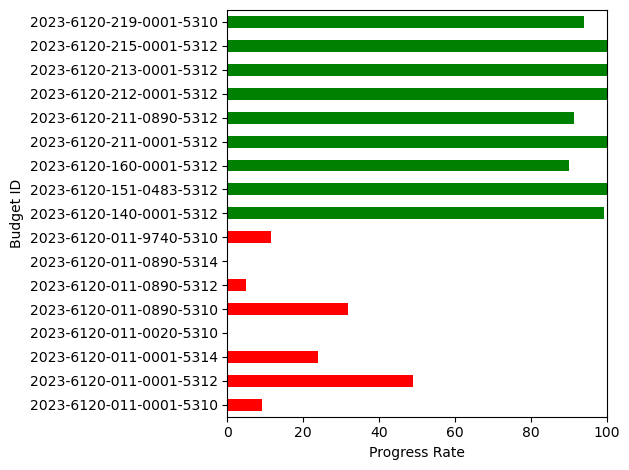

In [60]:
progress_6120.groupby("Budget_ID")["utilization_rate (%)"].mean().plot(kind="barh", color=["red" if x < 50 else "green" for x in progress_6120.groupby("Budget_ID")["utilization_rate (%)"].mean()])
plt.xlabel("Progress Rate")
plt.ylabel("Budget ID")
plt.xlim(0, 100)
plt.tight_layout()

# Out put this chart as "Progress_Rate_6120_Total.png"
plt.savefig("Progress_Rate_6120_Total.png")

plt.show()